In [55]:
# Pills classifier

# Этап 1. Загрузка и предобработка данных
# Результаты этапа
# Готовые для обучения датасеты с предобработкой, загруженные в DataLoader.
# Количество классов, изображений в обучающем и валидационном датасетах

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms.v2 import RandomRotation, RandomPhotometricDistort, \
RandomHorizontalFlip, RandomVerticalFlip, Compose
from torchvision.transforms import Resize
from torchvision.transforms import ToTensor, Normalize

train_dataset_path = 'dataset/ogyeiv2/train'
test_dataset_path = 'dataset/ogyeiv2/test'

train_dataset = ImageFolder(train_dataset_path)
test_dataset = ImageFolder(test_dataset_path)



In [56]:

classes = train_dataset.classes
print("Количество классов:", len(train_dataset.classes))
print("Список классов:", train_dataset.classes)
print("Размер train_dataset:", len(train_dataset))
print("Размер test_dataset:", len(test_dataset))



Количество классов: 84
Список классов: ['acc_long_600_mg', 'advil_ultra_forte', 'akineton_2_mg', 'algoflex_forte_dolo_400_mg', 'algoflex_rapid_400_mg', 'algopyrin_500_mg', 'ambroxol_egis_30_mg', 'apranax_550_mg', 'aspirin_ultra_500_mg', 'atoris_20_mg', 'atorvastatin_teva_20_mg', 'betaloc_50_mg', 'bila_git', 'c_vitamin_teva_500_mg', 'calci_kid', 'cataflam_50_mg', 'cataflam_dolo_25_mg', 'cetirizin_10_mg', 'cold_fx', 'coldrex', 'concor_10_mg', 'concor_5_mg', 'condrosulf_800_mg', 'controloc_20_mg', 'covercard_plus_10_mg_2_5_mg_5_mg', 'coverex_4_mg', 'diclopram_75-mg_20-mg', 'dorithricin_mentol', 'dulsevia_60_mg', 'enterol_250_mg', 'favipiravir_meditop_200_mg', 'ibumax_400_mg', 'jutavit_c_vitamin', 'jutavit_cink', 'kalcium_magnezium_cink', 'kalium_r', 'koleszterin_kontroll', 'lactamed', 'lactiv_plus', 'laresin_10_mg', 'letrox_50_mikrogramm', 'lordestin_5_mg', 'merckformin_xr_1000_mg', 'meridian', 'metothyrin_10_mg', 'mezym_forte_10_000_egyseg', 'milgamma', 'milurit_300_mg', 'naprosyn_250_mg

acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg
acc_long_600_mg


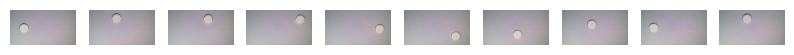

In [57]:
# Вывелем примеры пары изображений
from PIL import Image
from matplotlib import pyplot as plt

# Визуализация датасета до трансформаций
fig = plt.figure(figsize=(10,5))
for index in range (1, 11):
    image, label = train_dataset[index]
    print(train_dataset.classes[label])
    plt.subplot(1, 10, index)
    plt.imshow(image)
    plt.axis('off')


In [58]:


class TransformDataset(Dataset):
  def __init__(self, dataset, transforms):
    super(TransformDataset, self).__init__()
    self.dataset = dataset
    self.transforms = transforms

  def __len__(self):
    return len(self.dataset)

  def __getitem__(self, idx):
    x, y = self.dataset[idx]
    return self.transforms(x), y
  

train_transforms = Compose([
    RandomHorizontalFlip(p=0.2),
    RandomVerticalFlip(p=0.2),
    RandomRotation([-5, 5]),
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

test_transforms = Compose([
    Resize((224, 224)),
    ToTensor(),
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


train_dataset = TransformDataset(train_dataset, train_transforms)
val_dataset = TransformDataset(test_dataset, test_transforms)

batch_size = 32

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

In [59]:
import torchvision
from torchvision.models import resnet50
import torch.nn as nn
from torchsummary import summary


model = resnet50(weights='IMAGENET1K_V2')

print("Параметры модели", model)


Параметры модели ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1

In [60]:
summary(model, input_size=(3, 224, 224), device='cpu')


----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 64, 112, 112]           9,408
       BatchNorm2d-2         [-1, 64, 112, 112]             128
              ReLU-3         [-1, 64, 112, 112]               0
         MaxPool2d-4           [-1, 64, 56, 56]               0
            Conv2d-5           [-1, 64, 56, 56]           4,096
       BatchNorm2d-6           [-1, 64, 56, 56]             128
              ReLU-7           [-1, 64, 56, 56]               0
            Conv2d-8           [-1, 64, 56, 56]          36,864
       BatchNorm2d-9           [-1, 64, 56, 56]             128
             ReLU-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 256, 56, 56]          16,384
      BatchNorm2d-12          [-1, 256, 56, 56]             512
           Conv2d-13          [-1, 256, 56, 56]          16,384
      BatchNorm2d-14          [-1, 256,

In [61]:
# Ваш код для замены исходной архитектуры на указанную в задании

# Заморозка слоёв модели
for param in model.parameters():
    param.requires_grad = False

# Разморозка полносвязного слоя classifier
for param in model.fc.parameters():
    param.requires_grad = True

    
# Проверка


model.fc = nn.Linear(in_features=2048, out_features=len(classes), bias=True)

# Проверка
print(model)
summary(model, input_size=(3, 224, 224), device='cpu')

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 

In [ ]:
# Этап 3. Обучение или дообучение
# Обучите или дообучите классификатор на датасете таблеток. Сохраните обученную модель в файл meds_classifier.pt.  
 
import torch.optim as optim
import torch.nn as nn
import torch
from sklearn.metrics import classification_report


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(device)

# Код обучения для одной эпохи
def train_one_epoch(epoch_index):
    running_loss = 0.
    last_loss = 0.

    for batch_index, data in enumerate(train_loader):
        # Извлечение батча
        x, y = data
        x, y = x.to(device), y.to(device)
        # Обнуление градиентов
        optimizer.zero_grad()
        # Прямое распространение
        outputs = model.forward(x)
        # Подсчёт ошибки
        loss = criterion(outputs, y)
        # Обратное распространение
        loss.backward()
        # Обновление весов
        optimizer.step()

        # Суммирование ошибки за последние 20 батчей
        running_loss += loss.item()
        # print(batch_index)
        if batch_index % 20 == 19:
            last_loss = running_loss / 20. # средняя ошибка за 1000 батчей
            print(f'Эпоха: {epoch_index}, батч: {batch_index}, ошибка {last_loss}')
            running_loss = 0.

    return last_loss

EPOCHS = 10

best_vloss = 1e5
target_acc = 0.75
patient_count = 0

for epoch in range(EPOCHS):
    print(f'Эпоха {epoch}')

    # Ваш код для:
    # Перевода модели в режим обучения
    model.to(device)
    model.train(True)
    # Эпохи обучения (подсчёта средней функции потерь)
    avg_loss = train_one_epoch(epoch)
    # Перевода модели в режим валидации
    model.to('cpu')
    model.eval()
    running_vloss = 0.0
    correct_predictions = 0
    total_samples = 0
    # avg_vloss = 0.0
    # Валидация
    labels_predicted = []
    labels_true = []
    with torch.no_grad():
        for i, vdata in enumerate(val_loader):
            vinputs, vlabels = vdata
            # Ваш код для подсчёта ошибки на валидации
            outputs = model.forward(vinputs)
            vloss = criterion(outputs, vlabels)
            running_vloss += vloss

            # Считаем Accuracy
            _, predicted = torch.max(outputs, 1) # Получаем номера предсказанных классов
            
            # preds = predicted.cpu().numpy() 
            # labels_predicted.extend(preds)
            # labels_true.extend(vlabels.numpy())
            correct_predictions += (predicted == vlabels).sum().item()
            total_samples += vlabels.size(0)
            

    avg_vloss = running_vloss / (i + 1)
    accuracy = correct_predictions / total_samples
    # report = classification_report(labels_true, labels_predicted, target_names=classes, output_dict=True, zero_division=0)
    # print(classification_report(labels_true, labels_predicted, target_names=classes))
    # accuracy = report['accuracy']

    # Ваш код для сохранения лучшей модели

    if avg_vloss < best_vloss:
        best_vloss = avg_vloss
        model_path = f'meds_classifier.pt'
        torch.save(model.state_dict(), model_path)
        patient_count = 0
    else:
        patient_count += 1

    
    if accuracy >= target_acc:
        print(f'Достигнута точность {accuracy:.2%}. Прекращаем обучение.')
        break


    print(f'В конце эпохи ошибка train {avg_loss}, ошибка val {avg_vloss}')

    if patient_count == 2:
        break



cuda
Эпоха 0
Эпоха: 0, батч: 19, ошибка 4.434368228912353
Эпоха: 0, батч: 39, ошибка 4.290504884719849
Эпоха: 0, батч: 59, ошибка 4.017404699325562
В конце эпохи ошибка train 4.017404699325562, ошибка val 3.6812775135040283
Эпоха 1
Эпоха: 1, батч: 19, ошибка 3.6292915463447573
Эпоха: 1, батч: 39, ошибка 3.4956327080726624
Эпоха: 1, батч: 59, ошибка 3.330420637130737
В конце эпохи ошибка train 3.330420637130737, ошибка val 3.098027467727661
Эпоха 2
Эпоха: 2, батч: 19, ошибка 3.0277358174324034
Эпоха: 2, батч: 39, ошибка 2.9733373641967775
Эпоха: 2, батч: 59, ошибка 2.893230402469635
В конце эпохи ошибка train 2.893230402469635, ошибка val 2.671086072921753
Эпоха 3
Эпоха: 3, батч: 19, ошибка 2.5909847140312197
Эпоха: 3, батч: 39, ошибка 2.589825212955475
Эпоха: 3, батч: 59, ошибка 2.511955404281616
В конце эпохи ошибка train 2.511955404281616, ошибка val 2.313127279281616
Эпоха 4
Эпоха: 4, батч: 19, ошибка 2.31816942691803
Эпоха: 4, батч: 39, ошибка 2.289546012878418
Эпоха: 4, батч: 59, 

In [39]:
from sklearn.metrics import classification_report
labels_predicted = []
labels_true = []

model.eval()
model.to('cpu')

with torch.no_grad():
    for data in val_loader:
        images, labels = data

        outputs = model(images)
        _, predicted = torch.max(outputs, 1) # argmax по всем примерам
        labels_predicted.extend(predicted.numpy())
        labels_true.extend(labels.numpy())

print(classification_report(labels_true, labels_predicted, target_names=classes))

                                  precision    recall  f1-score   support

                 acc_long_600_mg       0.75      1.00      0.86         6
               advil_ultra_forte       1.00      1.00      1.00         6
                   akineton_2_mg       0.56      0.83      0.67         6
      algoflex_forte_dolo_400_mg       1.00      1.00      1.00         6
           algoflex_rapid_400_mg       1.00      1.00      1.00         6
                algopyrin_500_mg       0.80      0.67      0.73         6
             ambroxol_egis_30_mg       1.00      0.33      0.50         6
                  apranax_550_mg       1.00      1.00      1.00         6
            aspirin_ultra_500_mg       1.00      0.83      0.91         6
                    atoris_20_mg       0.62      0.83      0.71         6
         atorvastatin_teva_20_mg       0.46      1.00      0.63         6
                   betaloc_50_mg       1.00      0.83      0.91         6
                        bila_git     

/home/ubuntu/DL3/sprint3/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ubuntu/DL3/sprint3/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/ubuntu/DL3/sprint3/.venv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", le

In [ ]:
report = classification_report(labels_true, labels_predicted, target_names=classes, output_dict=True, zero_division=0)

pill_metrics = []
for key, value in report.items():
    if key in classes:
        pill_metrics.append((key, value['f1-score']))

# Сортируем по значению precision (от меньшего к большему)
pill_metrics.sort(key=lambda x: x[1])

# Выводим топ-5 худших
print("--- ТОП-5 КЛАССОВ С ХУДШЕЙ ТОЧНОСТЬЮ ПРЕДСКАЗАНИЙ ---")
for i in range(5):
    name, value = pill_metrics[i]
    print(f"{i+1}. {name}: {value:.2%}")

# Почему модель может ошибаться на этих классах?
print("")
print("Хуже всего результаты на белых таблетках без выраженных опознавательных знаков. Такие сложно отличить даже по фотографиям человеку")

precision_100 = [metric for metric in pill_metrics if metric[1] == 1]
print("")
print("--- ПРЕДСКАЗАНИЯ БЕЗ ОШИБОК ---")
for name, value in precision_100:
    # name, value = pill_metrics[-i-1]
    print(f"{name}: {value:.2%}")

print("")
print("Это классы с ярко выраженными признаками, которые отличаются от других классов: цвет, форма, надписи\n")

print("# Как можно улучшить точность классификатора?")
print("Можно попробовать использовать большее разрешение, чтобы повысить вероятность правильных предсказаний для похожих таблеток")
print("Можно попробовать другие модели с большим фокусом на распознование деталей. Архитектуры с GlobalMaxPooling вместо GlobalAveragePooling")

print("# Как ещё можно проанализировать результаты и ошибки модели?")
print("Так как ошибка на тренировочном и на валидационном датасетах все еще падают, то у модели еще есть потенциал к повышению точности предсказаниий после дообучения. ")


--- ТОП-5 КЛАССОВ С ХУДШЕЙ ТОЧНОСТЬЮ ПРЕДСКАЗАНИЙ ---
1. narva_sr_1_5_mg_retard: 0.00%
2. naturland_d_vitamin_forte: 22.22%
3. enterol_250_mg: 33.33%
4. teva_ambrobene_30_mg: 36.36%
5. sedatif_pc: 44.44%

Хуже всего результаты на белых таблетках без выраженных опознавательных знаков. Такие сложно отличить даже по фотографиям человеку

--- ПРЕДСКАЗАНИЯ БЕЗ ОШИБОК ---
advil_ultra_forte: 100.00%
algoflex_forte_dolo_400_mg: 100.00%
algoflex_rapid_400_mg: 100.00%
apranax_550_mg: 100.00%
c_vitamin_teva_500_mg: 100.00%
calci_kid: 100.00%
diclopram_75-mg_20-mg: 100.00%
jutavit_c_vitamin: 100.00%
koleszterin_kontroll: 100.00%
letrox_50_mikrogramm: 100.00%
mezym_forte_10_000_egyseg: 100.00%
milgamma: 100.00%
novo_c_plus: 100.00%
salazopyrin_en_500_mg: 100.00%
strepsils: 100.00%
urzinol: 100.00%
vita_c: 100.00%
zadex_60_mg: 100.00%

Это классы с ярко выраженными признаками, которые отличаются от других классов: цвет, форма, надписи

# Как можно улучшить точность классификатора?
Можно попробовать 

In [ ]:
# На каких 5 классах модель ошибается чаще всего?
# --- ТОП-5 КЛАССОВ С ХУДШЕЙ ТОЧНОСТЬЮ ПРЕДСКАЗАНИЙ ---
# 1. narva_sr_1_5_mg_retard: 0.00%
# 2. enterol_250_mg: 33.33%
# 3. naturland_d_vitamin_forte: 33.33%
# 4. normodipine_5_mg: 38.46%
# 5. teva_ambrobene_30_mg: 40.00%


# Почему модель может ошибаться на этих классах?
print("Хуже всего результаты на белых таблетках без выраженных опознавательных знаков. Такие сложно отличить даже по фотографиям человеку")
# На каких классах модель не совершает ошибок?
print("На классах с ярко выраженными признаками, которые отличаются от других классов: цвет, форма, надписи")
# Почему эти классы модель распознаёт безошибочно?
# Как можно улучшить точность классификатора?
# Как ещё можно проанализировать результаты и ошибки модели?